In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

n = 15000

departments = ['Cardiology', 'Orthopedics', 'Neurology', 'Pediatrics',
               'General Medicine', 'Emergency', 'Gynecology', 'Oncology',
               'Dermatology', 'Psychiatry']

dept_weights = [0.15, 0.12, 0.10, 0.12, 0.20, 0.10, 0.08, 0.06, 0.04, 0.03]

doctors = {
    'Cardiology': ['Dr. Sharma', 'Dr. Mehta', 'Dr. Iyer'],
    'Orthopedics': ['Dr. Patel', 'Dr. Reddy', 'Dr. Singh'],
    'Neurology': ['Dr. Kumar', 'Dr. Nair', 'Dr. Joshi'],
    'Pediatrics': ['Dr. Gupta', 'Dr. Rao', 'Dr. Verma'],
    'General Medicine': ['Dr. Mishra', 'Dr. Pillai', 'Dr. Shah', 'Dr. Das'],
    'Emergency': ['Dr. Khan', 'Dr. Thomas', 'Dr. Roy'],
    'Gynecology': ['Dr. Desai', 'Dr. Bose', 'Dr. Menon'],
    'Oncology': ['Dr. Kapoor', 'Dr. Sinha', 'Dr. Banerjee'],
    'Dermatology': ['Dr. Tiwari', 'Dr. Pandey'],
    'Psychiatry': ['Dr. Malhotra', 'Dr. Chatterjee']
}

disease_categories = {
    'Cardiology': ['Heart Attack', 'Hypertension', 'Arrhythmia', 'Heart Failure'],
    'Orthopedics': ['Fracture', 'Joint Pain', 'Spine Disorder', 'Sports Injury'],
    'Neurology': ['Stroke', 'Epilepsy', 'Migraine', 'Parkinsons'],
    'Pediatrics': ['Fever', 'Respiratory Infection', 'Malnutrition', 'Viral Infection'],
    'General Medicine': ['Diabetes', 'Fever', 'Infections', 'Hypertension', 'Anemia'],
    'Emergency': ['Accident', 'Poisoning', 'Burns', 'Trauma'],
    'Gynecology': ['Pregnancy', 'PCOS', 'Fibroids', 'Menstrual Disorder'],
    'Oncology': ['Breast Cancer', 'Lung Cancer', 'Blood Cancer', 'Colon Cancer'],
    'Dermatology': ['Eczema', 'Psoriasis', 'Acne', 'Fungal Infection'],
    'Psychiatry': ['Depression', 'Anxiety', 'Schizophrenia', 'Bipolar Disorder']
}

hospital_branches = ['Main Campus', 'North Wing', 'South Wing', 'East Campus']
age_groups = ['0-18', '19-35', '36-50', '51-65', '65+']
age_weights = [0.15, 0.25, 0.28, 0.20, 0.12]
admission_types = ['Emergency', 'Planned', 'Referral', 'Walk-in']
admission_weights = [0.25, 0.35, 0.20, 0.20]
treatment_status = ['Completed', 'Ongoing', 'Discharged', 'Transferred', 'LAMA']
treatment_weights = [0.55, 0.15, 0.20, 0.05, 0.05]

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

dept_col = np.random.choice(departments, n, p=dept_weights)
branch_col = np.random.choice(hospital_branches, n)
age_col = np.random.choice(age_groups, n, p=age_weights)
admission_col = np.random.choice(admission_types, n, p=admission_weights)
status_col = np.random.choice(treatment_status, n, p=treatment_weights)

doctor_col = [random.choice(doctors[d]) for d in dept_col]
disease_col = [random.choice(disease_categories[d]) for d in dept_col]

registration_times = [start_date + timedelta(
    seconds=random.randint(0, int((end_date - start_date).total_seconds()))
) for _ in range(n)]

hours = [t.hour for t in registration_times]
months = [t.month for t in registration_times]
days = [t.strftime('%A') for t in registration_times]

waiting_times = []
consultation_delays = []
diagnosis_delays = []
treatment_delays = []
discharge_delays = []
los_list = []

for i in range(n):
    dept = dept_col[i]
    adm = admission_col[i]
    hour = hours[i]

    base_wait = {
        'Emergency': 5, 'Cardiology': 25, 'Orthopedics': 30,
        'Neurology': 35, 'Pediatrics': 20, 'General Medicine': 40,
        'Gynecology': 28, 'Oncology': 20, 'Dermatology': 45, 'Psychiatry': 30
    }[dept]

    peak_multiplier = 1.5 if (9 <= hour <= 13 or 17 <= hour <= 20) else 1.0
    emergency_multiplier = 0.3 if adm == 'Emergency' else 1.0

    wait = max(2, int(base_wait * peak_multiplier * emergency_multiplier + random.gauss(0, 8)))
    waiting_times.append(wait)

    consult = max(5, int(random.gauss(20, 8)))
    consultation_delays.append(consult)

    diag = max(10, int(random.gauss(45, 20)))
    diagnosis_delays.append(diag)

    treat = max(30, int(random.gauss(120, 60)))
    treatment_delays.append(treat)

    disc = max(30, int(random.gauss(180, 90)))
    discharge_delays.append(disc)

    los_base = {
        'Emergency': 2, 'Cardiology': 5, 'Orthopedics': 7,
        'Neurology': 6, 'Pediatrics': 3, 'General Medicine': 4,
        'Gynecology': 4, 'Oncology': 10, 'Dermatology': 1, 'Psychiatry': 8
    }[dept]
    los = max(1, int(random.gauss(los_base, los_base * 0.4)))
    los_list.append(los)

readmission = []
for i in range(n):
    if status_col[i] == 'Discharged':
        prob = 0.08 if age_col[i] == '65+' else 0.05 if age_col[i] == '51-65' else 0.03
        readmission.append(1 if random.random() < prob else 0)
    else:
        readmission.append(0)

bed_occupied = [1 if s in ['Completed', 'Ongoing', 'Discharged'] else 0 for s in status_col]

satisfaction = []
for i in range(n):
    base = 7.0
    if waiting_times[i] > 60:
        base -= 1.5
    elif waiting_times[i] < 20:
        base += 0.5
    if los_list[i] > 10:
        base -= 0.5
    if status_col[i] == 'LAMA':
        base -= 2.0
    score = min(10, max(1, round(base + random.gauss(0, 1), 1)))
    satisfaction.append(score)

df = pd.DataFrame({
    'patient_id': [f'PAT{str(i+1).zfill(6)}' for i in range(n)],
    'registration_date': [t.strftime('%Y-%m-%d') for t in registration_times],
    'registration_time': [t.strftime('%H:%M:%S') for t in registration_times],
    'hour': hours,
    'month': months,
    'day_of_week': days,
    'department': dept_col,
    'doctor': doctor_col,
    'disease_category': disease_col,
    'hospital_branch': branch_col,
    'patient_age_group': age_col,
    'admission_type': admission_col,
    'treatment_status': status_col,
    'waiting_time_mins': waiting_times,
    'consultation_time_mins': consultation_delays,
    'diagnosis_time_mins': diagnosis_delays,
    'treatment_time_mins': treatment_delays,
    'discharge_time_mins': discharge_delays,
    'length_of_stay_days': los_list,
    'readmission_flag': readmission,
    'bed_occupied': bed_occupied,
    'patient_satisfaction_score': satisfaction,
})

df.to_csv('../data/hospital_raw.csv', index=False)
print("Dataset Generated!")
print(f"Total patients: {len(df):,}")
print(f"Departments: {df['department'].nunique()}")
print(f"Date range: {df['registration_date'].min()} to {df['registration_date'].max()}")
print(f"Readmission rate: {df['readmission_flag'].mean()*100:.2f}%")
df.head()

Dataset Generated!
Total patients: 15,000
Departments: 10
Date range: 2023-01-01 to 2024-12-30
Readmission rate: 0.80%


,patient_id,registration_date,registration_time,hour,month,day_of_week,department,doctor,disease_category,hospital_branch,...,treatment_status,waiting_time_mins,consultation_time_mins,diagnosis_time_mins,treatment_time_mins,discharge_time_mins,length_of_stay_days,readmission_flag,bed_occupied,patient_satisfaction_score
0,PAT000001,2024-05-18,19:33:59,19,5,Saturday,Pediatrics,Dr. Verma,Fever,East Campus,...,Ongoing,35,19,22,30,71,2,0,1,6.0
1,PAT000002,2024-09-08,13:20:46,13,9,Sunday,Dermatology,Dr. Tiwari,Eczema,North Wing,...,Discharged,75,27,53,182,40,1,0,1,3.9
2,PAT000003,2024-07-04,04:50:48,4,7,Thursday,Emergency,Dr. Khan,Poisoning,Main Campus,...,Completed,2,8,59,269,53,1,0,1,7.1
3,PAT000004,2023-06-13,07:17:06,7,6,Tuesday,General Medicine,Dr. Shah,Infections,East Campus,...,Completed,32,11,48,95,155,3,0,1,7.2
4,PAT000005,2024-05-11,01:14:37,1,5,Saturday,Orthopedics,Dr. Patel,Fracture,Main Campus,...,Completed,10,19,38,137,185,5,0,1,6.7


In [2]:
print("Shape before:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

df['efficiency_score'] = 100 - (
    (df['waiting_time_mins'] / df['waiting_time_mins'].max() * 30) +
    (df['length_of_stay_days'] / df['length_of_stay_days'].max() * 40) +
    (df['discharge_time_mins'] / df['discharge_time_mins'].max() * 30)
)
df['efficiency_score'] = df['efficiency_score'].round(1)

df['department_rating'] = pd.cut(
    df['efficiency_score'],
    bins=[0, 40, 70, 100],
    labels=['Low Efficiency', 'Medium Efficiency', 'High Efficiency']
)

df['total_process_time'] = (
    df['waiting_time_mins'] +
    df['consultation_time_mins'] +
    df['diagnosis_time_mins'] +
    df['treatment_time_mins'] +
    df['discharge_time_mins']
)

df['time_category'] = pd.cut(
    df['hour'],
    bins=[-1, 6, 12, 18, 23],
    labels=['Night (12AM-6AM)', 'Morning (6AM-12PM)',
            'Afternoon (12PM-6PM)', 'Evening (6PM-12AM)']
)

df.to_csv('../data/hospital_clean.csv', index=False)
print("Cleaning complete!")
print(f"Final shape: {df.shape}")
df.head()

Shape before: (15000, 22)
Missing values: 0
Duplicates: 0
Cleaning complete!
Final shape: (15000, 26)


,patient_id,registration_date,registration_time,hour,month,day_of_week,department,doctor,disease_category,hospital_branch,...,treatment_time_mins,discharge_time_mins,length_of_stay_days,readmission_flag,bed_occupied,patient_satisfaction_score,efficiency_score,department_rating,total_process_time,time_category
0,PAT000001,2024-05-18,19:33:59,19,5,Saturday,Pediatrics,Dr. Verma,Fever,East Campus,...,30,71,2,0,1,6.0,80.0,High Efficiency,177,Evening (6PM-12AM)
1,PAT000002,2024-09-08,13:20:46,13,9,Sunday,Dermatology,Dr. Tiwari,Eczema,North Wing,...,182,40,1,0,1,3.9,69.9,Medium Efficiency,377,Afternoon (12PM-6PM)
2,PAT000003,2024-07-04,04:50:48,4,7,Thursday,Emergency,Dr. Khan,Poisoning,Main Campus,...,269,53,1,0,1,7.1,94.3,High Efficiency,391,Night (12AM-6AM)
3,PAT000004,2023-06-13,07:17:06,7,6,Tuesday,General Medicine,Dr. Shah,Infections,East Campus,...,95,155,3,0,1,7.2,74.2,High Efficiency,341,Morning (6AM-12PM)
4,PAT000005,2024-05-11,01:14:37,1,5,Saturday,Orthopedics,Dr. Patel,Fracture,Main Campus,...,137,185,5,0,1,6.7,76.4,High Efficiency,389,Night (12AM-6AM)


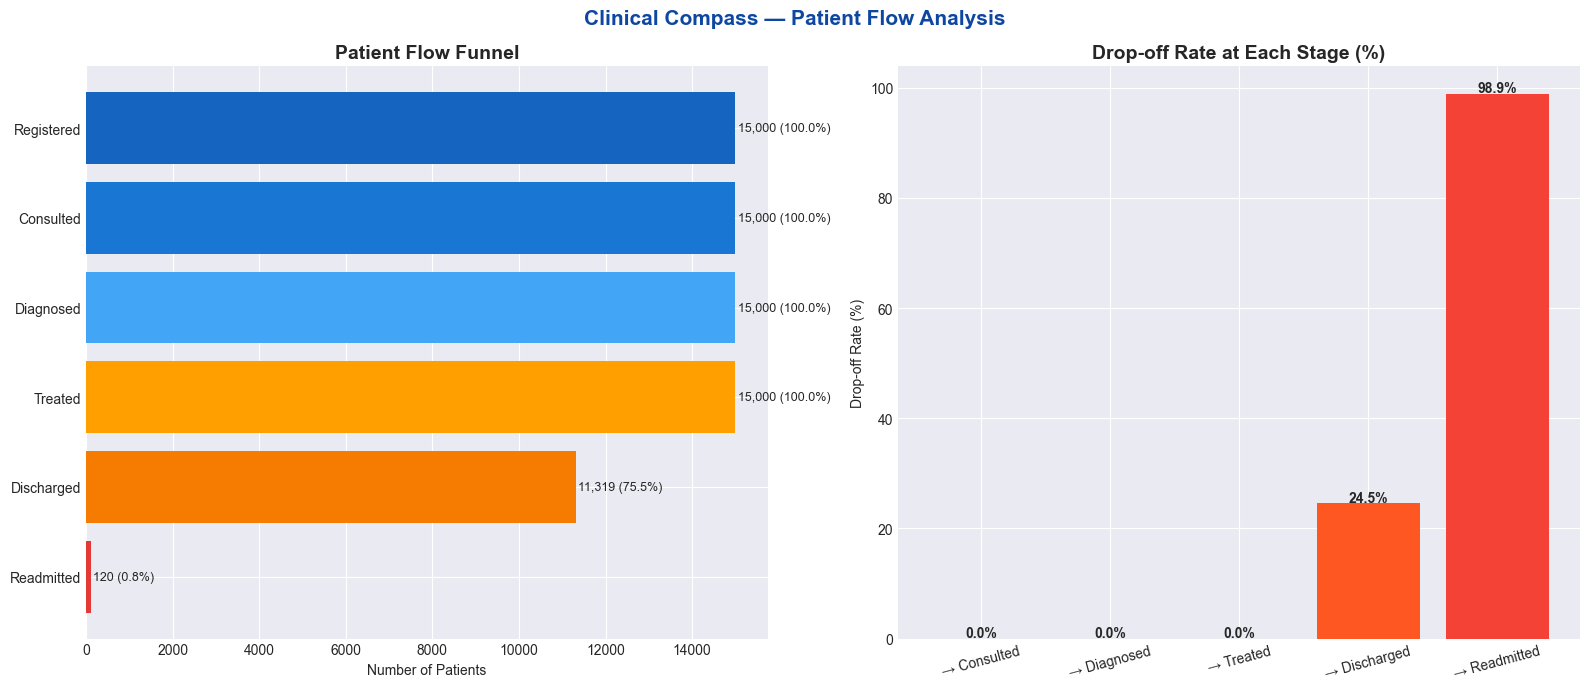

Chart 1 saved!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# CHART 1 — PATIENT FLOW FUNNEL
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

total_patients = len(df)
consulted = len(df[df['consultation_time_mins'] > 0])
diagnosed = len(df[df['diagnosis_time_mins'] > 0])
treated = len(df[df['treatment_time_mins'] > 0])
discharged = len(df[df['treatment_status'].isin(['Completed', 'Discharged'])])
readmitted = df['readmission_flag'].sum()

stages = ['Registered', 'Consulted', 'Diagnosed', 'Treated', 'Discharged', 'Readmitted']
counts = [total_patients, consulted, diagnosed, treated, discharged, readmitted]
colors = ['#1565C0','#1976D2','#42A5F5','#FFA000','#F57C00','#E53935']

axes[0].barh(stages[::-1], counts[::-1], color=colors[::-1])
axes[0].set_title('Patient Flow Funnel', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Patients')
for bar, val in zip(axes[0].patches, counts[::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/total_patients*100:.1f}%)',
                va='center', fontsize=9)

dropoffs = []
for i in range(1, len(counts)):
    rate = (1 - counts[i]/counts[i-1]) * 100
    dropoffs.append(rate)

drop_labels = ['→ Consulted', '→ Diagnosed', '→ Treated', '→ Discharged', '→ Readmitted']
bar_colors = ['#4CAF50','#4CAF50','#FFC107','#FF5722','#F44336']
bars = axes[1].bar(drop_labels, dropoffs, color=bar_colors)
axes[1].set_title('Drop-off Rate at Each Stage (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drop-off Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, dropoffs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Clinical Compass — Patient Flow Analysis', fontsize=15, fontweight='bold', color='#0D47A1')
plt.tight_layout()
plt.savefig('../outputs/chart1_patient_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

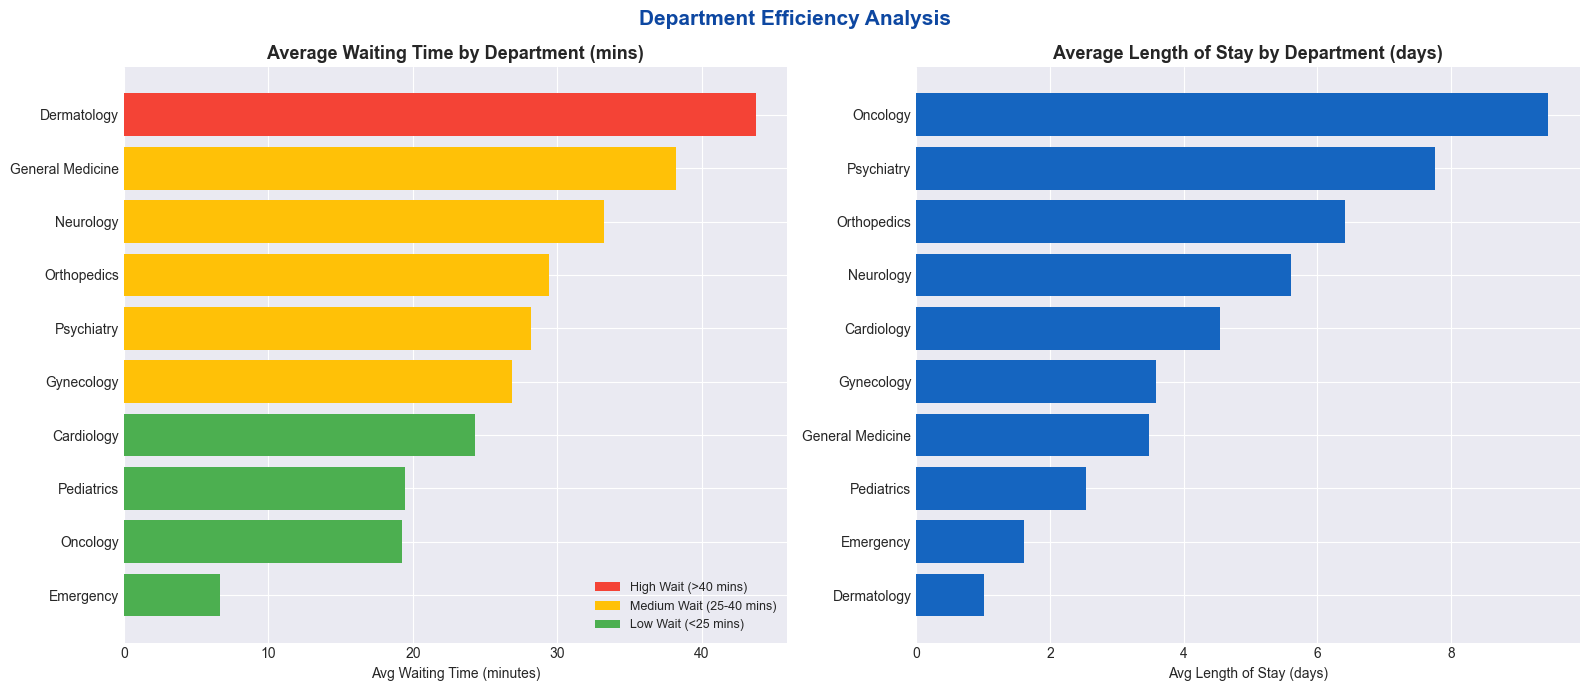

Chart 2 saved!


In [4]:
# CHART 2 — DEPARTMENT EFFICIENCY
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dept_stats = df.groupby('department').agg(
    avg_wait=('waiting_time_mins', 'mean'),
    avg_los=('length_of_stay_days', 'mean'),
    avg_satisfaction=('patient_satisfaction_score', 'mean'),
    total_patients=('patient_id', 'count'),
    avg_efficiency=('efficiency_score', 'mean')
).reset_index().round(2)

dept_stats_sorted = dept_stats.sort_values('avg_wait', ascending=True)
colors = ['#F44336' if w > 40 else '#FFC107' if w > 25 else '#4CAF50'
          for w in dept_stats_sorted['avg_wait']]
axes[0].barh(dept_stats_sorted['department'], dept_stats_sorted['avg_wait'], color=colors)
axes[0].set_title('Average Waiting Time by Department (mins)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Waiting Time (minutes)')
from matplotlib.patches import Patch
legend = [Patch(facecolor='#F44336', label='High Wait (>40 mins)'),
          Patch(facecolor='#FFC107', label='Medium Wait (25-40 mins)'),
          Patch(facecolor='#4CAF50', label='Low Wait (<25 mins)')]
axes[0].legend(handles=legend, fontsize=9)

dept_stats_los = dept_stats.sort_values('avg_los', ascending=True)
axes[1].barh(dept_stats_los['department'], dept_stats_los['avg_los'], color='#1565C0')
axes[1].set_title('Average Length of Stay by Department (days)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Length of Stay (days)')

plt.suptitle('Department Efficiency Analysis', fontsize=15, fontweight='bold', color='#0D47A1')
plt.tight_layout()
plt.savefig('../outputs/chart2_department_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

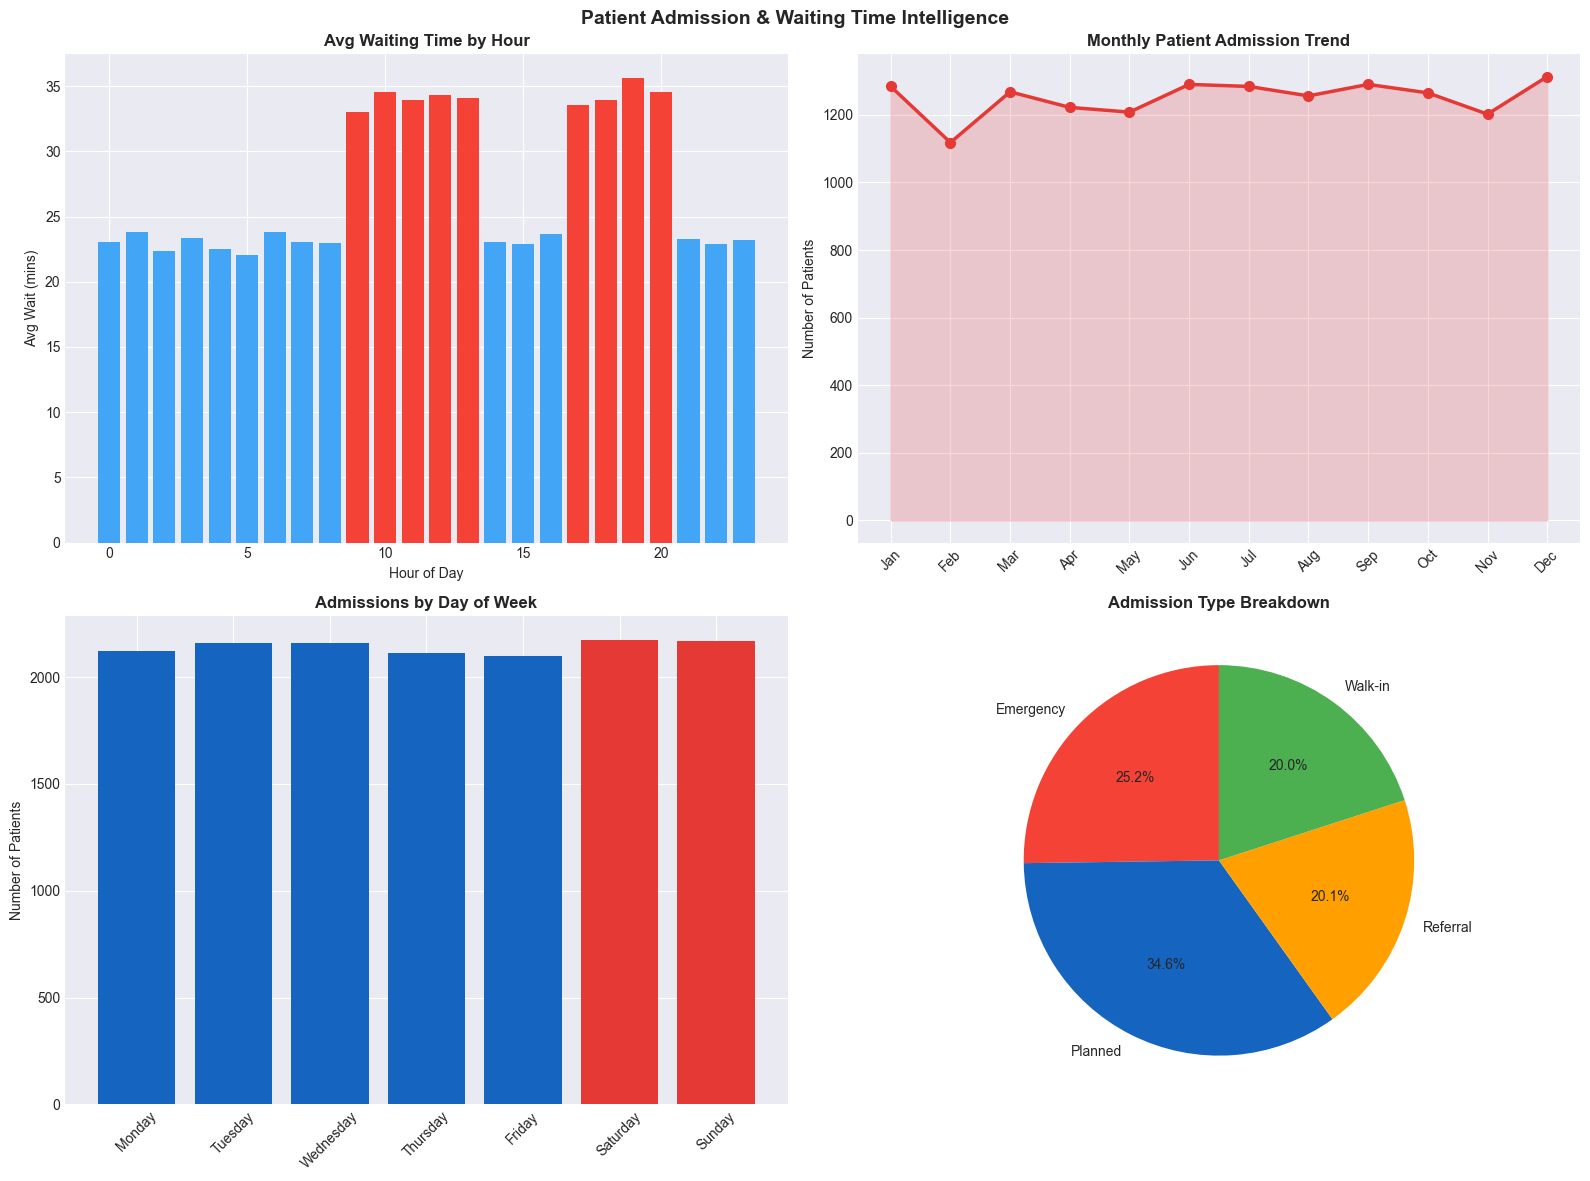

Chart 3 saved!


In [5]:
# CHART 3 — WAITING TIME ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

hourly = df.groupby('hour')['waiting_time_mins'].mean().reset_index()
peak_colors = ['#F44336' if (9 <= h <= 13 or 17 <= h <= 20) else '#42A5F5' for h in hourly['hour']]
axes[0,0].bar(hourly['hour'], hourly['waiting_time_mins'], color=peak_colors)
axes[0,0].set_title('Avg Waiting Time by Hour', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Avg Wait (mins)')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month')['patient_id'].count().reset_index()
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])
axes[0,1].plot(monthly['month_name'], monthly['patient_id'],
               marker='o', linewidth=2.5, color='#E53935', markersize=7)
axes[0,1].fill_between(range(len(monthly)), monthly['patient_id'], alpha=0.2, color='#E53935')
axes[0,1].set_title('Monthly Patient Admission Trend', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Number of Patients')
axes[0,1].set_xticks(range(len(monthly)))
axes[0,1].set_xticklabels(monthly['month_name'], rotation=45)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_data = df.groupby('day_of_week')['patient_id'].count().reset_index()
day_data['day_of_week'] = pd.Categorical(day_data['day_of_week'], categories=day_order, ordered=True)
day_data = day_data.sort_values('day_of_week')
weekend_colors = ['#E53935' if d in ['Saturday','Sunday'] else '#1565C0' for d in day_order]
axes[1,0].bar(day_order, day_data['patient_id'], color=weekend_colors)
axes[1,0].set_title('Admissions by Day of Week', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Number of Patients')
axes[1,0].tick_params(axis='x', rotation=45)

adm_type = df.groupby('admission_type')['patient_id'].count().reset_index()
axes[1,1].pie(adm_type['patient_id'], labels=adm_type['admission_type'],
              autopct='%1.1f%%', startangle=90,
              colors=['#F44336','#1565C0','#FFA000','#4CAF50'])
axes[1,1].set_title('Admission Type Breakdown', fontsize=12, fontweight='bold')

plt.suptitle('Patient Admission & Waiting Time Intelligence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart3_waiting_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

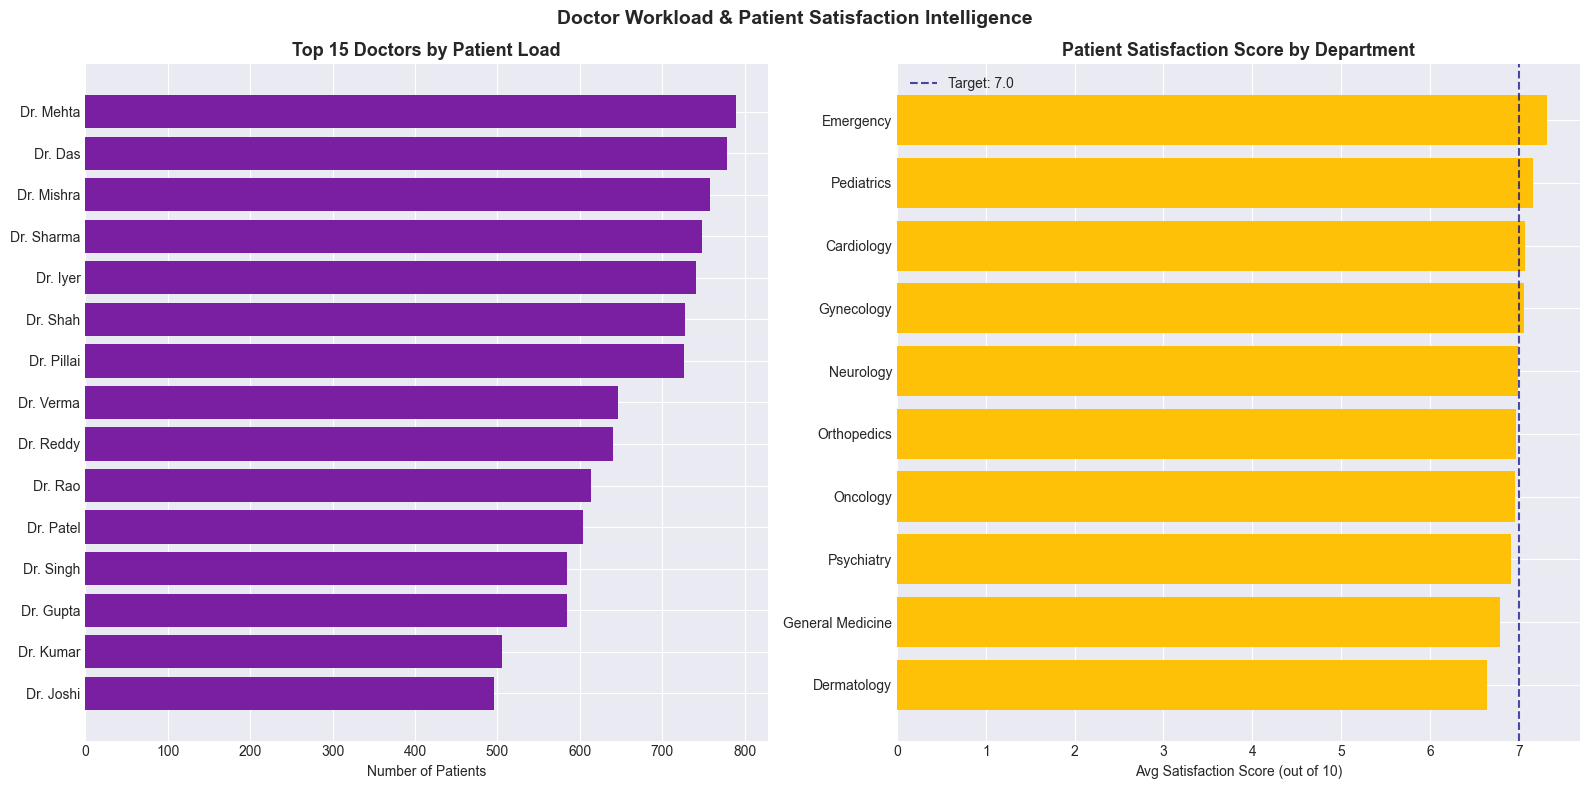

Chart 4 saved!


In [6]:
# CHART 4 — DOCTOR WORKLOAD
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

doctor_load = df.groupby(['doctor','department']).agg(
    patients=('patient_id','count'),
    avg_satisfaction=('patient_satisfaction_score','mean')
).reset_index().sort_values('patients', ascending=True).tail(15)

axes[0].barh(doctor_load['doctor'], doctor_load['patients'], color='#7B1FA2')
axes[0].set_title('Top 15 Doctors by Patient Load', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Patients')

dept_satisfaction = df.groupby('department')['patient_satisfaction_score'].mean().reset_index()
dept_satisfaction = dept_satisfaction.sort_values('patient_satisfaction_score', ascending=True)
sat_colors = ['#F44336' if s < 6 else '#FFC107' if s < 7.5 else '#4CAF50'
              for s in dept_satisfaction['patient_satisfaction_score']]
axes[1].barh(dept_satisfaction['department'], dept_satisfaction['patient_satisfaction_score'],
             color=sat_colors)
axes[1].set_title('Patient Satisfaction Score by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Satisfaction Score (out of 10)')
axes[1].axvline(x=7, color='navy', linestyle='--', alpha=0.7, label='Target: 7.0')
axes[1].legend()

plt.suptitle('Doctor Workload & Patient Satisfaction Intelligence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart4_doctor_workload.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

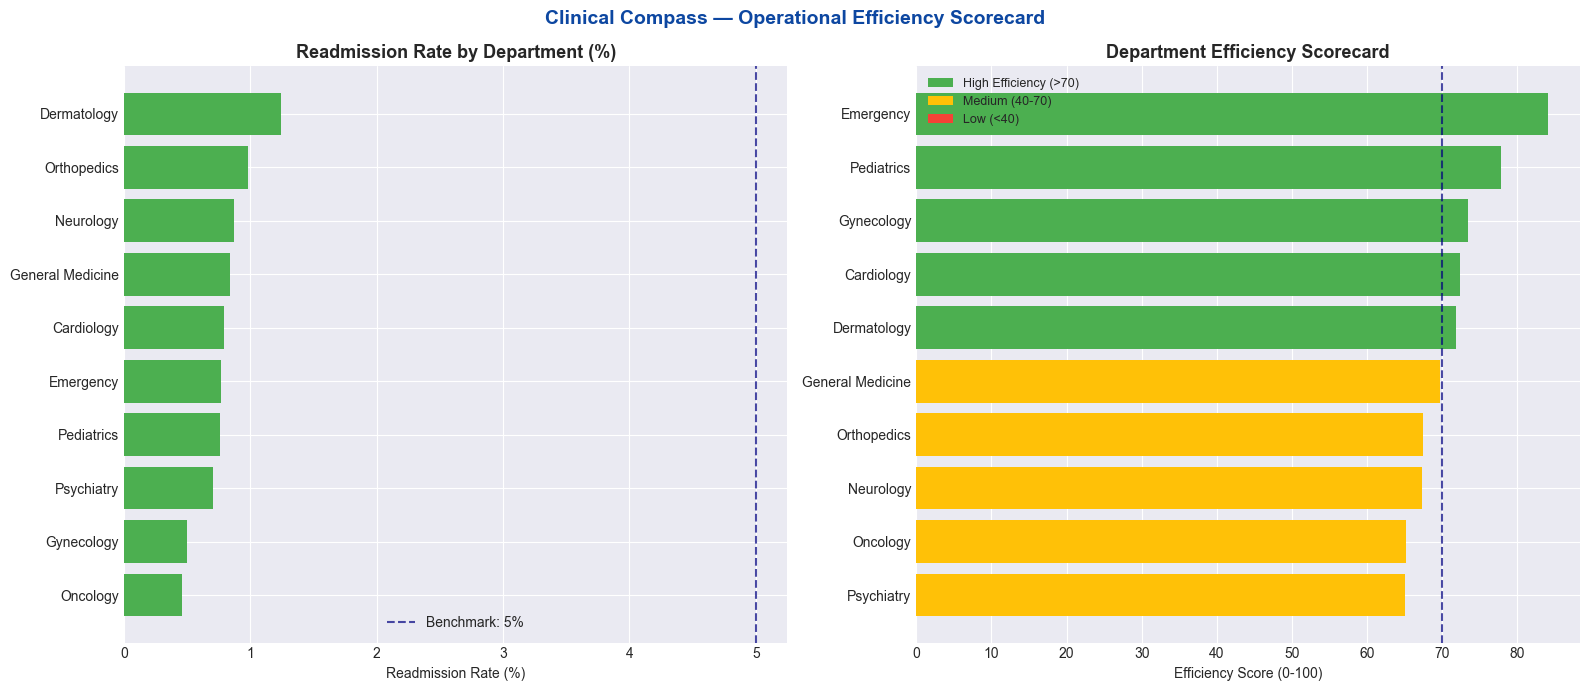

Chart 5 saved!


In [7]:
# CHART 5 — READMISSION & EFFICIENCY SCORECARD
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

readmission_dept = df.groupby('department').agg(
    total=('patient_id','count'),
    readmitted=('readmission_flag','sum')
).reset_index()
readmission_dept['readmission_rate'] = readmission_dept['readmitted']/readmission_dept['total']*100
readmission_dept = readmission_dept.sort_values('readmission_rate', ascending=True)
r_colors = ['#F44336' if r > 6 else '#FFC107' if r > 4 else '#4CAF50'
            for r in readmission_dept['readmission_rate']]
axes[0].barh(readmission_dept['department'], readmission_dept['readmission_rate'], color=r_colors)
axes[0].set_title('Readmission Rate by Department (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].axvline(x=5, color='navy', linestyle='--', alpha=0.7, label='Benchmark: 5%')
axes[0].legend()

efficiency_dept = df.groupby('department')['efficiency_score'].mean().reset_index()
efficiency_dept = efficiency_dept.sort_values('efficiency_score', ascending=True)
eff_colors = ['#F44336' if e < 40 else '#FFC107' if e < 70 else '#4CAF50'
              for e in efficiency_dept['efficiency_score']]
axes[1].barh(efficiency_dept['department'], efficiency_dept['efficiency_score'], color=eff_colors)
axes[1].set_title('Department Efficiency Scorecard', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Efficiency Score (0-100)')
axes[1].axvline(x=70, color='navy', linestyle='--', alpha=0.7, label='Target: 70')
axes[1].legend()
from matplotlib.patches import Patch
legend = [Patch(facecolor='#4CAF50', label='High Efficiency (>70)'),
          Patch(facecolor='#FFC107', label='Medium (40-70)'),
          Patch(facecolor='#F44336', label='Low (<40)')]
axes[1].legend(handles=legend, fontsize=9)

plt.suptitle('Clinical Compass — Operational Efficiency Scorecard', fontsize=14, fontweight='bold', color='#0D47A1')
plt.tight_layout()
plt.savefig('../outputs/chart5_efficiency_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [8]:
import sqlite3

conn = sqlite3.connect('../data/hospital.db')
df.to_sql('patients', conn, if_exists='replace', index=False)
print(f"Database created with {len(df):,} rows")

import pandas as pd

print("="*60)
print("QUERY 1: Department Performance Overview")
print("="*60)
q1 = pd.read_sql_query("""
    SELECT department,
           COUNT(*) as total_patients,
           ROUND(AVG(waiting_time_mins), 1) as avg_wait_mins,
           ROUND(AVG(length_of_stay_days), 1) as avg_los_days,
           ROUND(AVG(patient_satisfaction_score), 2) as avg_satisfaction,
           ROUND(AVG(efficiency_score), 1) as avg_efficiency
    FROM patients
    GROUP BY department
    ORDER BY avg_efficiency DESC
""", conn)
print(q1.to_string(index=False))

print("\n" + "="*60)
print("QUERY 2: Patient Funnel Analysis")
print("="*60)
q2 = pd.read_sql_query("""
    SELECT treatment_status,
           COUNT(*) as count,
           ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM patients), 2) as percentage,
           ROUND(AVG(waiting_time_mins), 1) as avg_wait,
           ROUND(AVG(length_of_stay_days), 1) as avg_los
    FROM patients
    GROUP BY treatment_status
    ORDER BY count DESC
""", conn)
print(q2.to_string(index=False))

print("\n" + "="*60)
print("QUERY 3: Peak Hours Analysis with Window Function")
print("="*60)
q3 = pd.read_sql_query("""
    SELECT hour,
           COUNT(*) as admissions,
           ROUND(AVG(waiting_time_mins), 1) as avg_wait,
           SUM(COUNT(*)) OVER (ORDER BY hour) as cumulative_admissions,
           CASE
               WHEN hour BETWEEN 9 AND 13 THEN 'Morning Peak'
               WHEN hour BETWEEN 17 AND 20 THEN 'Evening Peak'
               WHEN hour BETWEEN 0 AND 6 THEN 'Night Hours'
               ELSE 'Normal Hours'
           END as time_classification
    FROM patients
    GROUP BY hour
    ORDER BY hour
""", conn)
print(q3.to_string(index=False))

print("\n" + "="*60)
print("QUERY 4: Doctor Workload with RANK()")
print("="*60)
q4 = pd.read_sql_query("""
    SELECT doctor,
           department,
           COUNT(*) as total_patients,
           ROUND(AVG(patient_satisfaction_score), 2) as avg_satisfaction,
           ROUND(AVG(waiting_time_mins), 1) as avg_wait_mins,
           RANK() OVER (PARTITION BY department ORDER BY COUNT(*) DESC) as dept_rank
    FROM patients
    GROUP BY doctor, department
    ORDER BY total_patients DESC
    LIMIT 15
""", conn)
print(q4.to_string(index=False))

print("\n" + "="*60)
print("QUERY 5: Readmission Analysis by Department")
print("="*60)
q5 = pd.read_sql_query("""
    SELECT department,
           COUNT(*) as total_discharged,
           SUM(readmission_flag) as readmitted,
           ROUND(SUM(readmission_flag)*100.0/COUNT(*), 2) as readmission_rate,
           CASE
               WHEN SUM(readmission_flag)*100.0/COUNT(*) > 6 THEN 'HIGH RISK'
               WHEN SUM(readmission_flag)*100.0/COUNT(*) > 4 THEN 'MEDIUM RISK'
               ELSE 'LOW RISK'
           END as risk_level
    FROM patients
    WHERE treatment_status = 'Discharged'
    GROUP BY department
    ORDER BY readmission_rate DESC
""", conn)
print(q5.to_string(index=False))

print("\n" + "="*60)
print("QUERY 6: Monthly Trend with Moving Average")
print("="*60)
q6 = pd.read_sql_query("""
    SELECT month,
           COUNT(*) as admissions,
           ROUND(AVG(waiting_time_mins), 1) as avg_wait,
           ROUND(AVG(COUNT(*)) OVER (
               ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
           ), 1) as moving_avg_3month
    FROM patients
    GROUP BY month
    ORDER BY month
""", conn)
print(q6.to_string(index=False))

print("\n" + "="*60)
print("QUERY 7: Efficiency Scorecard with CTE")
print("="*60)
q7 = pd.read_sql_query("""
    WITH dept_metrics AS (
        SELECT department,
               COUNT(*) as total_patients,
               AVG(waiting_time_mins) as avg_wait,
               AVG(length_of_stay_days) as avg_los,
               AVG(efficiency_score) as avg_efficiency,
               AVG(patient_satisfaction_score) as avg_satisfaction,
               SUM(readmission_flag)*100.0/COUNT(*) as readmission_rate
        FROM patients
        GROUP BY department
    )
    SELECT department,
           ROUND(avg_efficiency, 1) as efficiency_score,
           ROUND(avg_wait, 1) as avg_wait_mins,
           ROUND(avg_los, 1) as avg_los_days,
           ROUND(avg_satisfaction, 2) as satisfaction,
           ROUND(readmission_rate, 2) as readmission_pct,
           CASE
               WHEN avg_efficiency > 70 THEN '🟢 HIGH EFFICIENCY'
               WHEN avg_efficiency > 40 THEN '🟡 MEDIUM EFFICIENCY'
               ELSE '🔴 LOW EFFICIENCY'
           END as efficiency_rating
    FROM dept_metrics
    ORDER BY avg_efficiency DESC
""", conn)
print(q7.to_string(index=False))

conn.close()
print("\n✅ ALL SQL QUERIES COMPLETE!")

Database created with 15,000 rows
QUERY 1: Department Performance Overview
      department  total_patients  avg_wait_mins  avg_los_days  avg_satisfaction  avg_efficiency
       Emergency            1426            6.7           1.6              7.32            84.2
      Pediatrics            1844           19.4           2.5              7.16            77.9
      Gynecology            1194           26.9           3.6              7.05            73.4
      Cardiology            2278           24.3           4.5              7.07            72.3
     Dermatology             643           43.7           1.0              6.64            71.9
General Medicine            2990           38.2           3.5              6.79            69.7
     Orthopedics            1829           29.4           6.4              6.97            67.5
       Neurology            1497           33.2           5.6              6.99            67.3
        Oncology             873           19.3           9.5

In [9]:
sql_content = """
-- ================================================
-- CLINICAL COMPASS
-- Hospital Operations Analytics
-- SQL Analysis Queries
-- ================================================

-- Query 1: Department Performance Overview
SELECT department,
       COUNT(*) as total_patients,
       ROUND(AVG(waiting_time_mins), 1) as avg_wait_mins,
       ROUND(AVG(length_of_stay_days), 1) as avg_los_days,
       ROUND(AVG(patient_satisfaction_score), 2) as avg_satisfaction,
       ROUND(AVG(efficiency_score), 1) as avg_efficiency
FROM patients
GROUP BY department
ORDER BY avg_efficiency DESC;

-- Query 2: Patient Funnel Analysis
SELECT treatment_status,
       COUNT(*) as count,
       ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM patients), 2) as percentage,
       ROUND(AVG(waiting_time_mins), 1) as avg_wait,
       ROUND(AVG(length_of_stay_days), 1) as avg_los
FROM patients
GROUP BY treatment_status
ORDER BY count DESC;

-- Query 3: Peak Hours with Window Function
SELECT hour,
       COUNT(*) as admissions,
       ROUND(AVG(waiting_time_mins), 1) as avg_wait,
       SUM(COUNT(*)) OVER (ORDER BY hour) as cumulative_admissions,
       CASE
           WHEN hour BETWEEN 9 AND 13 THEN 'Morning Peak'
           WHEN hour BETWEEN 17 AND 20 THEN 'Evening Peak'
           WHEN hour BETWEEN 0 AND 6 THEN 'Night Hours'
           ELSE 'Normal Hours'
       END as time_classification
FROM patients
GROUP BY hour
ORDER BY hour;

-- Query 4: Doctor Workload with RANK()
SELECT doctor,
       department,
       COUNT(*) as total_patients,
       ROUND(AVG(patient_satisfaction_score), 2) as avg_satisfaction,
       RANK() OVER (PARTITION BY department ORDER BY COUNT(*) DESC) as dept_rank
FROM patients
GROUP BY doctor, department
ORDER BY total_patients DESC
LIMIT 15;

-- Query 5: Readmission Analysis
SELECT department,
       COUNT(*) as total_discharged,
       SUM(readmission_flag) as readmitted,
       ROUND(SUM(readmission_flag)*100.0/COUNT(*), 2) as readmission_rate,
       CASE
           WHEN SUM(readmission_flag)*100.0/COUNT(*) > 6 THEN 'HIGH RISK'
           WHEN SUM(readmission_flag)*100.0/COUNT(*) > 4 THEN 'MEDIUM RISK'
           ELSE 'LOW RISK'
       END as risk_level
FROM patients
WHERE treatment_status = 'Discharged'
GROUP BY department
ORDER BY readmission_rate DESC;

-- Query 6: Monthly Trend with Moving Average
SELECT month,
       COUNT(*) as admissions,
       ROUND(AVG(waiting_time_mins), 1) as avg_wait,
       ROUND(AVG(COUNT(*)) OVER (
           ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
       ), 1) as moving_avg_3month
FROM patients
GROUP BY month
ORDER BY month;

-- Query 7: Efficiency Scorecard with CTE
WITH dept_metrics AS (
    SELECT department,
           COUNT(*) as total_patients,
           AVG(waiting_time_mins) as avg_wait,
           AVG(length_of_stay_days) as avg_los,
           AVG(efficiency_score) as avg_efficiency,
           AVG(patient_satisfaction_score) as avg_satisfaction,
           SUM(readmission_flag)*100.0/COUNT(*) as readmission_rate
    FROM patients
    GROUP BY department
)
SELECT department,
       ROUND(avg_efficiency, 1) as efficiency_score,
       ROUND(avg_wait, 1) as avg_wait_mins,
       ROUND(avg_los, 1) as avg_los_days,
       ROUND(avg_satisfaction, 2) as satisfaction,
       ROUND(readmission_rate, 2) as readmission_pct,
       CASE
           WHEN avg_efficiency > 70 THEN 'HIGH EFFICIENCY'
           WHEN avg_efficiency > 40 THEN 'MEDIUM EFFICIENCY'
           ELSE 'LOW EFFICIENCY'
       END as efficiency_rating
FROM dept_metrics
ORDER BY avg_efficiency DESC;
"""

with open('../sql/hospital_queries.sql', 'w') as f:
    f.write(sql_content)

print("SQL file saved!")

SQL file saved!
